Model Değerlendirme ve Karşılaştırma

Bu notebook'ta:
1. Eğitilmiş LSTM ve GRU modellerini yükleyeceğiz.
2. Test seti üzerinde tahmin (prediction) yapacağız.
3. Tahminleri `-1 ile 1` aralığından gerçek USD fiyatlarına geri çevireceğiz (`inverse_transform`).
4. Modellerin başarısını RMSE (Root Mean Squared Error) ile ölçeceğiz.
5. Gerçek vs. Tahmin grafiklerini çizeceğiz.
6. LSTM ve GRU'yu karşılaştıracağız.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
import math
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("Kütüphaneler yüklendi")

# LSTM Sınıfı
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

# GRU Sınıfı
class GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn) = self.gru(x, (h0.detach()))
        out = self.fc(out[:, -1, :])
        return out

print("Model sınıfları tanımlandı")

Kütüphaneler yüklendi
Model sınıfları tanımlandı


In [2]:
# 1. Tensörleri yükle
tensors = torch.load('../data/tensors.pt', weights_only=True)
x_train = tensors['x_train']
y_train = tensors['y_train']
x_test = tensors['x_test']
y_test = tensors['y_test']

# 2. Scaler'ı yükle (fiyatları geri çevirmek için çok önemli!)
with open('../data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 3. Eğitim geçmişini ve hiperparametreleri yükle
with open('../data/training_history.pkl', 'rb') as f:
    history = pickle.load(f)
hp = history['hyperparams']

# 4. Metadata'yı yükle (tarihleri grafiklerde kullanmak için)
with open('../data/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

print("Veriler başarıyla yüklendi")
print(f"Test verisi boyutu: {x_test.shape[0]} örnek")

Veriler başarıyla yüklendi
Test verisi boyutu: 724 örnek


In [3]:
# Boş modelleri oluştur (kaydedilen hiperparametrelerle)
model_lstm = LSTM(hp['input_dim'], hp['hidden_dim'], hp['num_layers'], hp['output_dim'])
model_gru = GRU(hp['input_dim'], hp['hidden_dim'], hp['num_layers'], hp['output_dim'])

# Eğitilmiş ağırlıkları (weights) yükle
model_lstm.load_state_dict(torch.load('../data/model_lstm.pt', weights_only=True))
model_gru.load_state_dict(torch.load('../data/model_gru.pt', weights_only=True))

# Modelleri değerlendirme (evaluation) moduna al
# Dropout, BatchNorm gibi katmanların davranışını test moduna göre ayarlar
model_lstm.eval()
model_gru.eval()

print("Eğitilmiş modeller yüklendi ve evaluation moduna alındı")

Eğitilmiş modeller yüklendi ve evaluation moduna alındı


In [4]:
with torch.no_grad():
    # Eğitim seti tahminleri (modelin öğrendiğini görmek için)
    train_predict_lstm = model_lstm(x_train).numpy()
    train_predict_gru = model_gru(x_train).numpy()

    # Test seti tahminleri (modelin hiç görmediği verideki başarısı)
    test_predict_lstm = model_lstm(x_test).numpy()
    test_predict_gru = model_gru(x_test).numpy()

print("Tahminler yapıldı")
print(f"Test tahmini örnek şekli: {test_predict_lstm.shape}")
print(f"İlk 3 tahmin (normalize değerler):")
print("LSTM")
print(test_predict_lstm[:3].flatten())
print("GRU")
print(test_predict_gru[:3].flatten())

Tahminler yapıldı
Test tahmini örnek şekli: (724, 1)
İlk 3 tahmin (normalize değerler):
LSTM
[-0.06946299 -0.05704075 -0.04822282]
GRU
[-0.01065917 -0.00732654 -0.01645939]


In [5]:
# Gerçek değerleri geri çevir
y_train_actual = scaler.inverse_transform(y_train.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# LSTM tahminlerini geri çevir
train_predict_lstm_usd = scaler.inverse_transform(train_predict_lstm)
test_predict_lstm_usd = scaler.inverse_transform(test_predict_lstm)

# GRU tahminlerini geri çevir
train_predict_gru_usd = scaler.inverse_transform(train_predict_gru)
test_predict_gru_usd = scaler.inverse_transform(test_predict_gru)

print("USD fiyatlarına geri çevirme işlemi tamamlandı")
print(f"\nİlk 3 Gerçek Fiyat:  {y_test_actual[:3].flatten()}")
print(f"İlk 3 LSTM Tahmin:   {test_predict_lstm_usd[:3].flatten()}")
print(f"İlk 3 GRU Tahmin:    {test_predict_gru_usd[:3].flatten()}")

USD fiyatlarına geri çevirme işlemi tamamlandı

İlk 3 Gerçek Fiyat:  [139.94 137.85 138.56]
İlk 3 LSTM Tahmin:   [132.64795 134.3013  135.47495]
İlk 3 GRU Tahmin:    [140.47455 140.9181  139.70255]


In [6]:
# RMSE Hesaplama Fonksiyonu
def calculate_rmse(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = math.sqrt(mse)
    return mse, rmse

# LSTM Hataları
lstm_train_mse, lstm_train_rmse = calculate_rmse(y_train_actual, train_predict_lstm_usd)
lstm_test_mse, lstm_test_rmse = calculate_rmse(y_test_actual, test_predict_lstm_usd)

# GRU Hataları
gru_train_mse, gru_train_rmse = calculate_rmse(y_train_actual, train_predict_gru_usd)
gru_test_mse, gru_test_rmse = calculate_rmse(y_test_actual, test_predict_gru_usd)

print("MODEL PERFORMANS SONUÇLARI")
print(f"LSTM Train RMSE : ${lstm_train_rmse:.2f}")
print(f"LSTM Test RMSE  : ${lstm_test_rmse:.2f}")
print(f"GRU Train RMSE  : ${gru_train_rmse:.2f}")
print(f"GRU Test RMSE   : ${gru_test_rmse:.2f}")

winner = "GRU" if gru_test_rmse < lstm_test_rmse else "LSTM"
diff = abs(lstm_test_rmse - gru_test_rmse)
print(f"Kazanan: {winner} (Test setinde ${diff:.2f} daha az hata yaptı)")

MODEL PERFORMANS SONUÇLARI
LSTM Train RMSE : $3.27
LSTM Test RMSE  : $17.02
GRU Train RMSE  : $2.21
GRU Test RMSE   : $11.83
Kazanan: GRU (Test setinde $5.19 daha az hata yaptı)


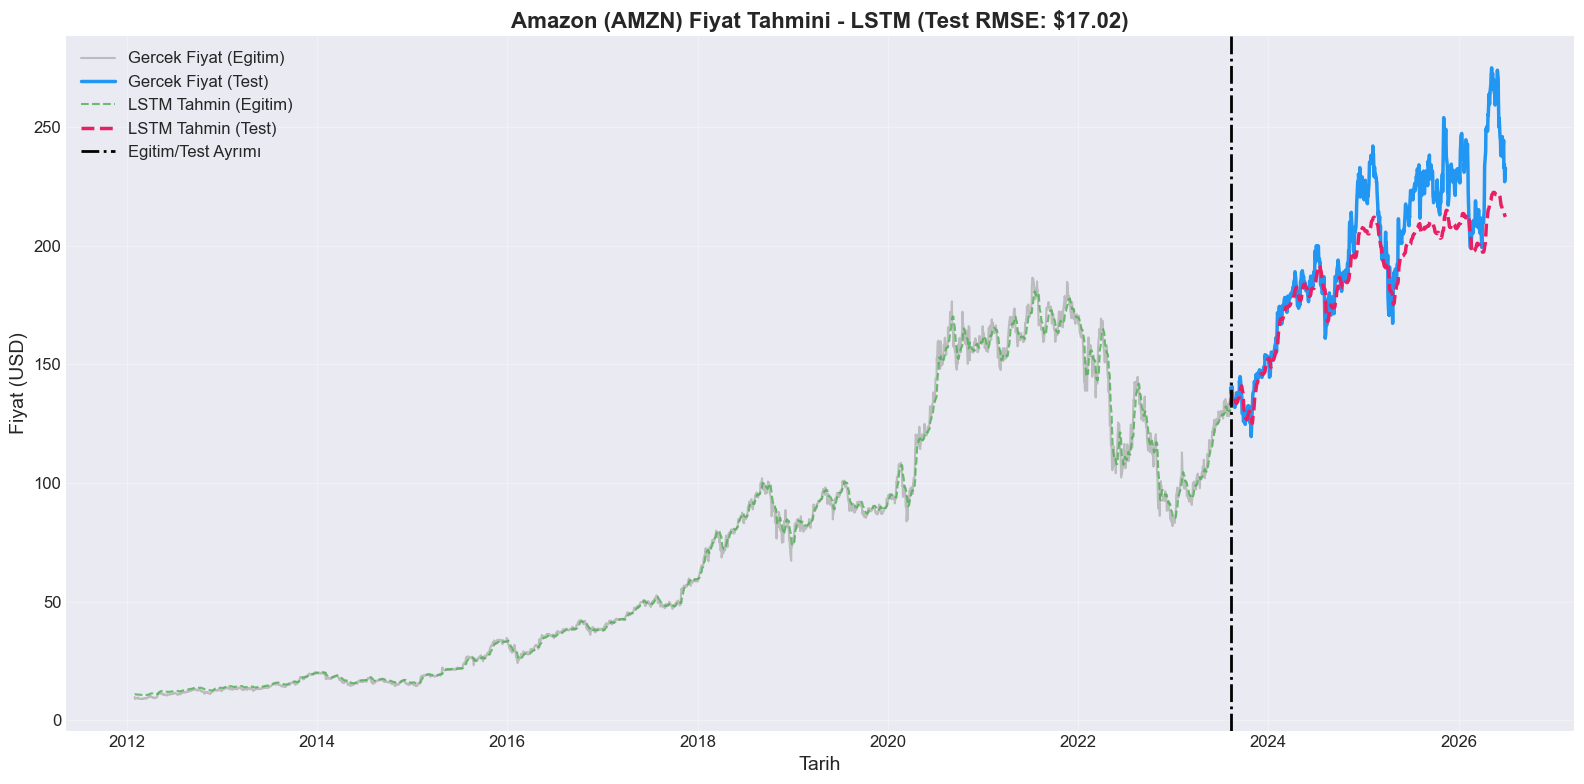

Grafik kaydedildi: results/prediction_lstm.png


In [7]:
# Tarihleri hazirla (Grafik X ekseni icin)
# Orijinal verideki tarihleri almak icin data'yi okuyalim (sadece index'i)
data = pd.read_csv("../data/AMZN.csv", index_col=0, parse_dates=True)

# Lookback kadar gun bastan silinmisti
dates = data.index[metadata['lookback']:]

# Egitim ve test icin tarihleri ayir
split_point = len(y_train_actual)
train_dates = dates[:split_point]
test_dates = dates[split_point:]

# LSTM Grafigi
fig, ax = plt.subplots(figsize=(16, 8))

# Gercek fiyatlari ciz
ax.plot(train_dates, y_train_actual, color='#9E9E9E', linewidth=1.5, alpha=0.6, label='Gercek Fiyat (Egitim)')
ax.plot(test_dates, y_test_actual, color='#2196F3', linewidth=2.5, label='Gercek Fiyat (Test)')

# Tahminleri ciz
ax.plot(train_dates, train_predict_lstm_usd, color='#4CAF50', linewidth=1.5, linestyle='--', alpha=0.8, label='LSTM Tahmin (Egitim)')
ax.plot(test_dates, test_predict_lstm_usd, color='#E91E63', linewidth=2.5, linestyle='--', label='LSTM Tahmin (Test)')

# Egitim/Test ayrım cizgisi
ax.axvline(x=test_dates[0], color='black', linestyle='-.', linewidth=2, label='Egitim/Test Ayrımı')

ax.set_title(f'Amazon (AMZN) Fiyat Tahmini - LSTM (Test RMSE: ${lstm_test_rmse:.2f})', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=14)
ax.set_ylabel('Fiyat (USD)', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/prediction_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/prediction_lstm.png")

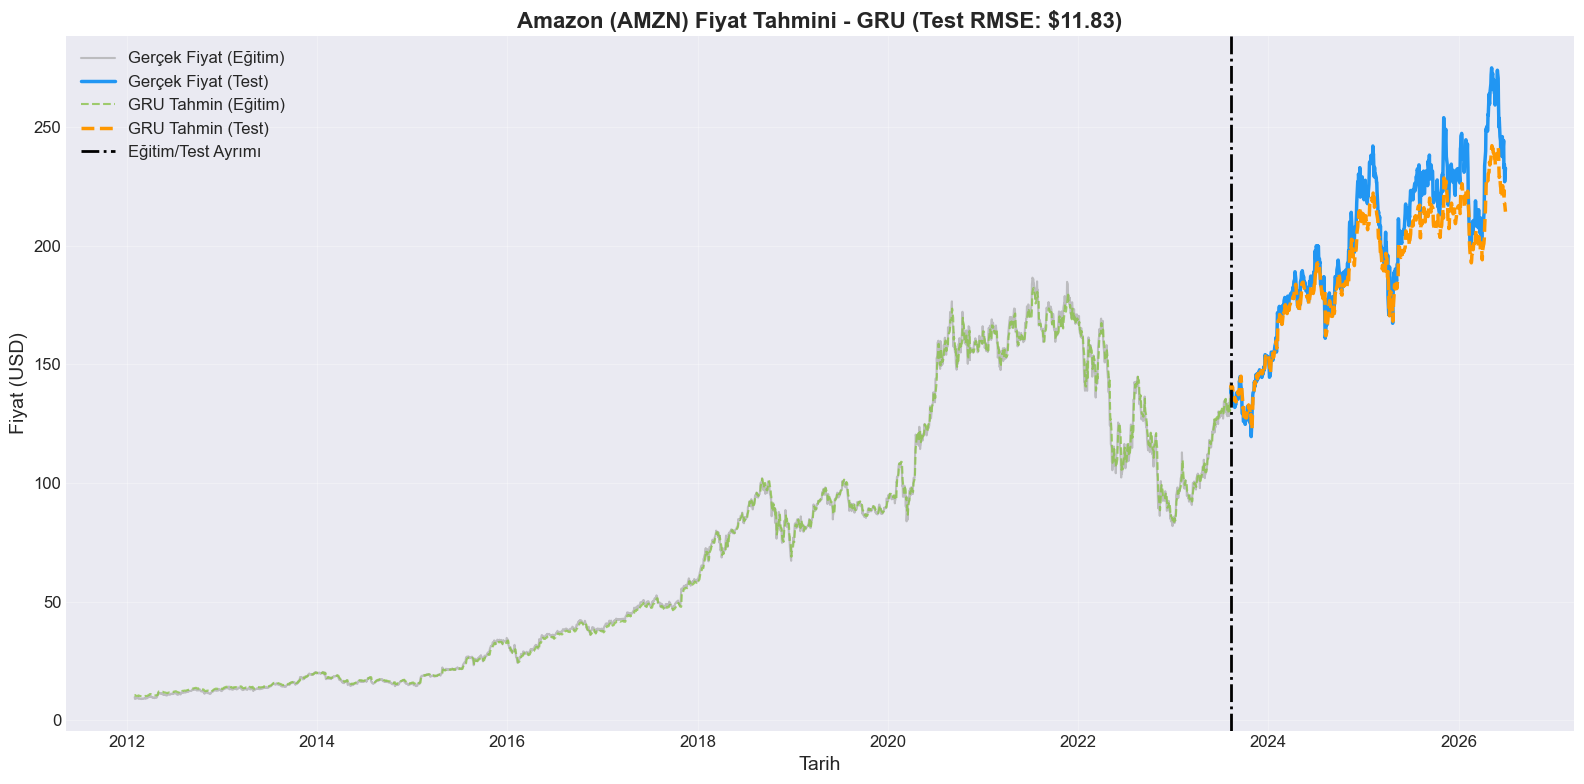

Grafik kaydedildi: results/prediction_gru.png


In [8]:
# GRU Grafiği
fig, ax = plt.subplots(figsize=(16, 8))

# Gerçek fiyatları çiz
ax.plot(train_dates, y_train_actual, color='#9E9E9E', linewidth=1.5, alpha=0.6, label='Gerçek Fiyat (Eğitim)')
ax.plot(test_dates, y_test_actual, color='#2196F3', linewidth=2.5, label='Gerçek Fiyat (Test)')

# Tahminleri çiz
ax.plot(train_dates, train_predict_gru_usd, color='#8BC34A', linewidth=1.5, linestyle='--', alpha=0.8, label='GRU Tahmin (Eğitim)')
ax.plot(test_dates, test_predict_gru_usd, color='#FF9800', linewidth=2.5, linestyle='--', label='GRU Tahmin (Test)')

# Eğitim/Test ayrım çizgisi
ax.axvline(x=test_dates[0], color='black', linestyle='-.', linewidth=2, label='Eğitim/Test Ayrımı')

ax.set_title(f'Amazon (AMZN) Fiyat Tahmini - GRU (Test RMSE: ${gru_test_rmse:.2f})', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=14)
ax.set_ylabel('Fiyat (USD)', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/prediction_gru.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/prediction_gru.png")

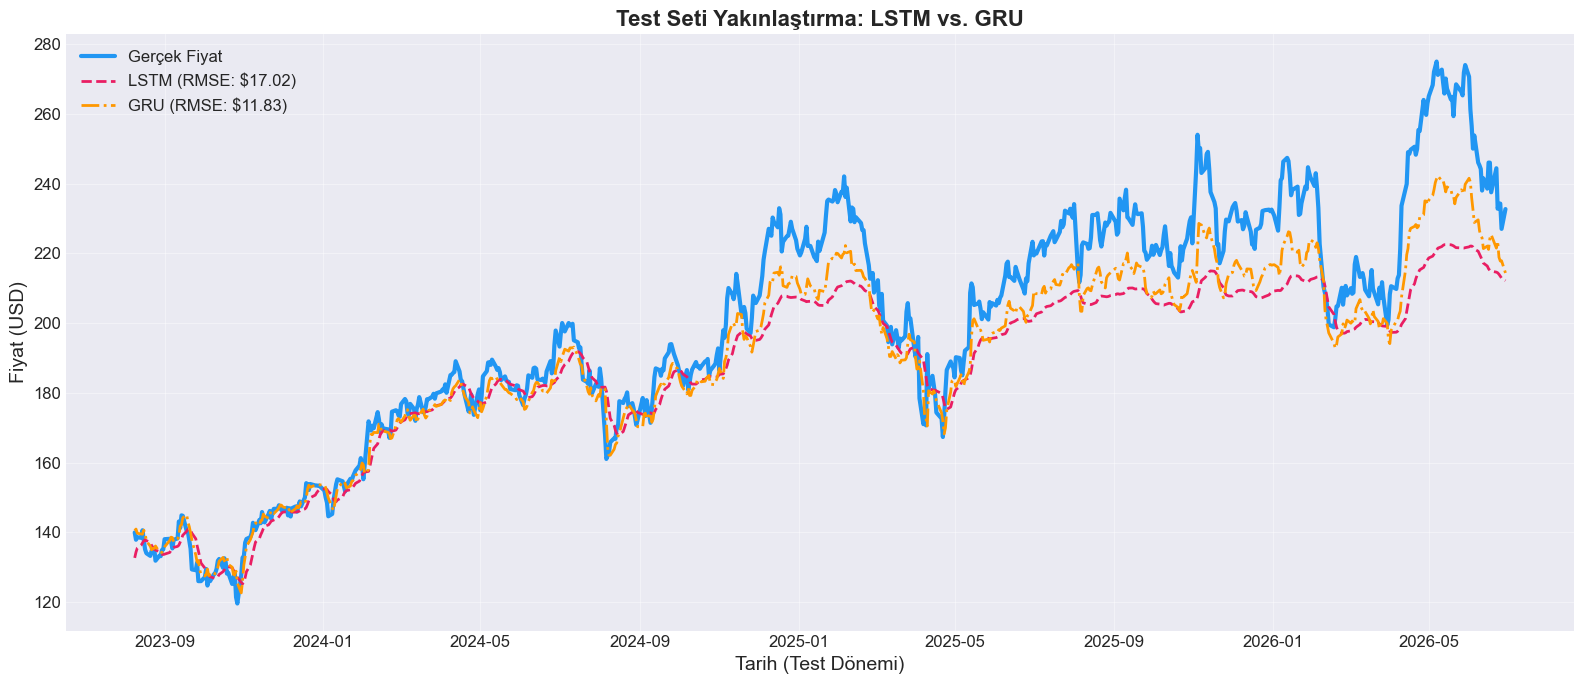

Grafik kaydedildi: results/prediction_test_zoom.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

# Sadece test tarihlerindeki gerçek fiyat
ax.plot(test_dates, y_test_actual, color='#2196F3', linewidth=3, label='Gerçek Fiyat')

# LSTM Tahmini
ax.plot(test_dates, test_predict_lstm_usd, color='#E91E63', linewidth=2, linestyle='--',
        label=f'LSTM (RMSE: ${lstm_test_rmse:.2f})')

# GRU Tahmini
ax.plot(test_dates, test_predict_gru_usd, color='#FF9800', linewidth=2, linestyle='-.',
        label=f'GRU (RMSE: ${gru_test_rmse:.2f})')

ax.set_title('Test Seti Yakınlaştırma: LSTM vs. GRU', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih (Test Dönemi)', fontsize=14)
ax.set_ylabel('Fiyat (USD)', fontsize=14)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../results/prediction_test_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/prediction_test_zoom.png")

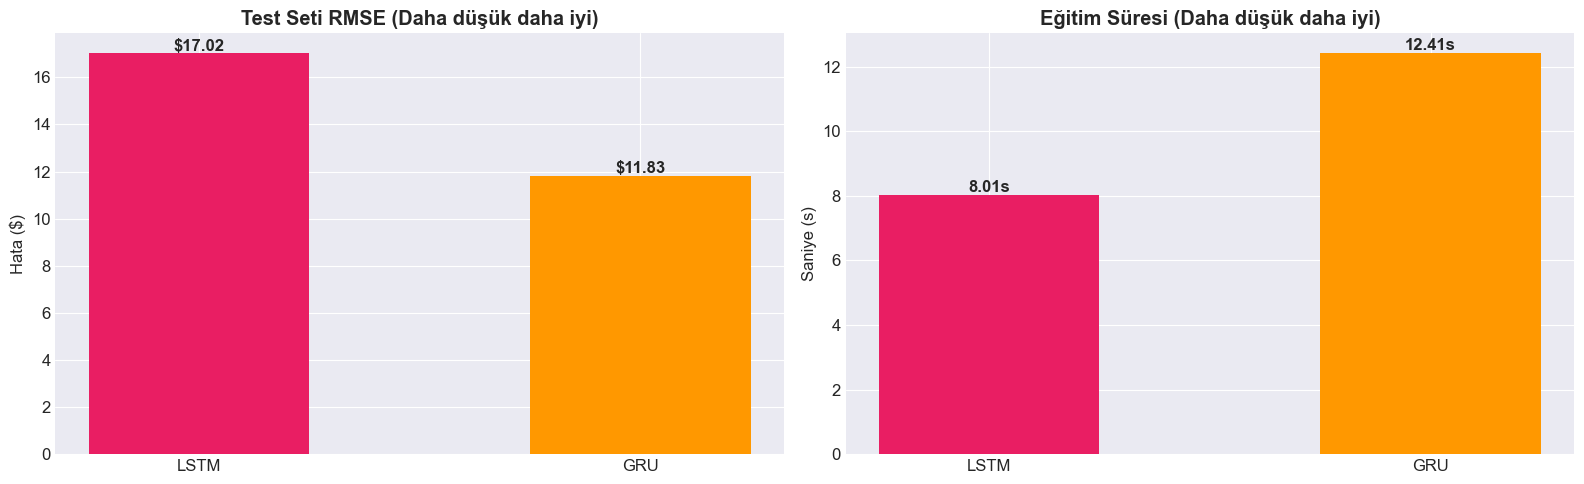

Grafik kaydedildi: results/model_comparison.png


In [10]:
# Karşılaştırma Grafiği (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
models = ['LSTM', 'GRU']
colors = ['#E91E63', '#FF9800']

# RMSE Karşılaştırması
axes[0].bar(models, [lstm_test_rmse, gru_test_rmse], color=colors, width=0.5)
axes[0].set_title('Test Seti RMSE (Daha düşük daha iyi)', fontweight='bold')
axes[0].set_ylabel('Hata ($)')
for i, v in enumerate([lstm_test_rmse, gru_test_rmse]):
    axes[0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontweight='bold')

# Süre Karşılaştırması (training_history.pkl'den gelir)
time_lstm = history['time_lstm']
time_gru = history['time_gru']
axes[1].bar(models, [time_lstm, time_gru], color=colors, width=0.5)
axes[1].set_title('Eğitim Süresi (Daha düşük daha iyi)', fontweight='bold')
axes[1].set_ylabel('Saniye (s)')
for i, v in enumerate([time_lstm, time_gru]):
    axes[1].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/model_comparison.png")